# Python Tutorial 

The code in this notebook is provided to act as support for lower year students and should be similar to whats already been seen before.
## Why Use Python Libraries? 

In physics, we're often trying to model complex systems, analyze large datasets, or visualize results. Writing the code to do all of this from scratch would be far to much work! This is where libraries come in!

**A library is just a collection of pre-written code (functions, objects, etc.) that you can "import" into your own script.** 


### Why They're Amazing for Physics:
Don't reinvent the wheel, as much as we all love going down rabbit holes and getting side tracked, it turns out using highly optimized, bug-tested functions written by experts its much more efficent. Some other reasons are:
* **Performance:** Libraries like NumPy run calculations in compiled C code under the hood, making them *much* faster than standard Python loops for large arrays of data.
* **Readability:** Your code becomes cleaner and focuses on the *physics* problem you're solving, not the low-level programming details.
* **Functionality:** They provide powerful tools that are simply not available in standard Python.


### The "Big Four" for your phyiscs undergrad:

You'll use these three libraries in almost every physics coding problem or lab.

#### 1. NumPy

* **What it does:** NumPy's main feature is the **`ndarray` (n-dimensional array)**. This object lets you create and manipulate vectors, matrices, and higher-dimensional arrays efficiently.
* **Why you'll use it:**
    * Storing experimental data (e.g., a list of time measurements).
    * Performing fast mathematical operations on entire arrays at once.
    * Linear algebra problems.
    * Generating arrays of numbers, like a time axis for a simulation.

#### 2. SciPy 

* **What it does:** SciPy is built *on top* of NumPy. It provides a huge collection of higher-level scientific algorithms.
* **Why you'll use it:**
    * **Integration:** Numerically solving integrals.
    * **ODEs:** Solving ordinary differential equations (like modeling a damped oscillator).
    * **Optimization:** Finding the minimum or maximum of a function (fitting curves to a set of data points).
    * **Statistics:** Performing statistical analysis on your data.

#### 3. Matplotlib

* **What it does:** This is the standard library for creating high-quality, publication-ready plots and visualisations.
* **Why you'll use it:**
    * Making 2D line plots.
    * Creating scatter plots to visualise experimental data.
    * Plotting histograms to see the distribution of measurements.
    * Visualising 3D surfaces or vector fields.
    * **Communicating your results!** A plot is often the most important part of your analysis.

#### 4. Pandas

* **What it does:** Pandas introduces a powerful object called the `DataFrame`. Think of it as a smart, programmable spreadsheet or table, built on top of NumPy.
* **Why you'll use it:**
    * Loading Data: Easily reading data from files (like `.csv` or `.txt` files from a lab) into a clean table.
    * Data Cleaning: Handling messy data, like dropping bad measurements (e.g., `NaN` values) or selecting only the data you need.
    * Labeling: Working with data that has labels, like column headers ("Time (s)", "Voltage (V)") or timestamps.
    * Filtering & Grouping: Quickly selecting or grouping data based on conditions (e.g., "all measurements where voltage > 5V").

## What libraries did I mention? and how do we import them in to our notebook?

It's possible to to define a "alias" for the libraries when you import them. This can make your code more concise as you wont have to type out the full library name each time you use it. You can choose any alias you like, but I've used the most common conventions below - especially useful when collaborating on a project.

In [20]:
import numpy as np 
import scipy as sc 
import matplotlib.pyplot as plt
import pandas as pd

Note that instead of importing the entire **matplotlib** library, I have used: `import matplotlib.pyplot as plt`. The **pyplot** module is a sub-library within **matplotlib** that provides most of the commonly used functions for visualizing data - such as plotting lines, bars, and scatter plots. In most cases, this is all you'll need.

## First of all read in from the csv

In [21]:
decay_data = pd.read_csv('decay_data.csv')

## Can you print the "DataFrame"

In [22]:
decay_data.style

,Time,Counts,Error
0,0,4976.505967,70.600000
1,5,3531.030982,59.240000
2,10,2480.385950,50.200000
3,15,1748.795652,41.770000
4,20,1244.041934,35.070000
5,25,885.565195,29.870000
6,30,581.988057,24.800000
7,35,383.078046,20.980000
8,40,306.901270,17.460000
9,45,180.664849,14.560000


There are several methods to display the DataFrame, but using `style` let's you customise how the table is formatted. 

This is a small DataFrame, so printing it displays the entire contents. For larger DataFrames, however, Python will truncate the output and only show the first few rows. If this happens and you need to view the full DataFrame, you can either open the .csv file directly or adjust the pandas display settings:

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

You can also index a DataFrame to view a specific column. This is one of the key advantages of using a DataFrame over a plain array. Rather than remembering which index corresponds to the data you want, you can simply refer to the column by name. For example:

In [6]:
display(decay_data['Time'])

0      0
1      5
2     10
3     15
4     20
5     25
6     30
7     35
8     40
9     45
10    50
Name: Time, dtype: int64

To find out the names of the columns, you can use:

In [7]:
print(decay_data.columns)

Index(['Time', 'Counts', 'Error'], dtype='object')


## Now try plotting the data

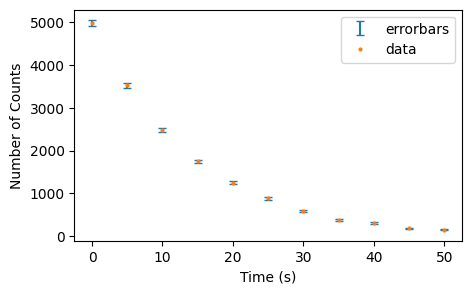

In [8]:
plt.figure(figsize=(5, 3))  # Create a new figure with custom size (5 inches wide, 3 inches tall)

# Plot error bars without markers (just the vertical lines)
plt.errorbar(
    decay_data['Time'], decay_data['Counts'],
    yerr=decay_data['Error'],
    fmt=' ',              # No marker
    capsize=3,            # Length of error bar caps
    label='errorbars'     # Label for legend
)

# Overlay the actual data points with small circular markers
plt.errorbar(
    decay_data['Time'], decay_data['Counts'],
    fmt='o',              # Circular marker
    ms=2,                 # Marker size
    label='data'          # Label for legend
)

# Axis labels
plt.ylabel('Number of Counts')
plt.xlabel('Time (s)')

# Add legend to distinguish error bars and data points
plt.legend()

# Display the plot
plt.show()

This plot is just one example of how you can visualise data using Matplotlib. The library offers a wide range of customisable options: from adjusting marker styles, colours, and line types to configuring axes, annotations, and interactive elements.

## How can we write a nuclear counts formula in python?

The formula for exponential decay, and therefore the expected number of counts at time t, is:

$$ N(t) = N_0 e^{-\lambda t} $$

where:
- $N_0$ is the initial number of counts
- $\lambda$ is the decay constant
- $t$ is the time

A function can be defined in Python which calculates the number of counts for given parameters using this formula:

In [9]:
def nuclearcounts(t, N0, lam): 
    return N0 * np.exp(-lam * t)

It's common practice for the first parameter to represent the independent variable - the quantity the model is a function of (in this case that is time, t). This will become important later.

To check that this is working as expected, you can input some example values and plot the results to see if you get the expected curve shape.

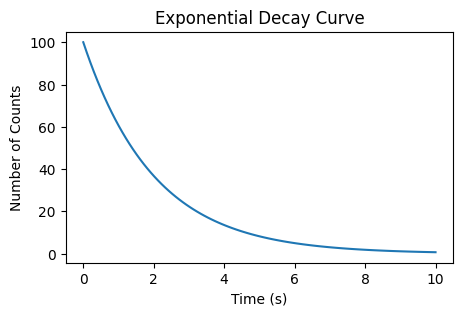

In [10]:
# Example parameters
t = np.linspace(0, 10, 100)  # Time from 0 to 10 seconds
N0 = 100                     # Initial count
lam = 0.5                    # Decay constant

# Calculate counts
decay_curve = nuclearcounts(t, N0, lam)

# Plot
plt.figure(figsize=(5,3))
plt.plot(t, decay_curve)
plt.xlabel('Time (s)')
plt.ylabel('Number of Counts')
plt.title('Exponential Decay Curve')
plt.show()

Note that this time I’ve chosen to plot only the curve formed by the data, rather than displaying each point individually. This is for two reasons:

- I’m not interested in any one specific point—what matters here is the overall shape of the decay.
- There are far more data points in this case (100 compared to 10), and plotting them all individually would make the graph look cluttered.

As you can see, the function is working as expected.

## Using the librarys we mentioned and answers from google/ ai how could we fit an eqn of best fit to the data?

To fit an exponential decay model to your experimental data, you can use the curve_fit function from the scipy.optimize module. This function estimates the parameters of your model—in this case, the initial count $N_0$ and decay constant $\lambda$ —by minimising the difference between your data and the model prediction. This is why I needed time to be the first parameter in the function because curve_fit assumes that the first argument passed to your model represents the independent variable. If the order is incorrect, curve_fit won’t know which values to vary during fitting, and the optimisation will fail or produce misleading results. By placing time first, the function signature matches what curve_fit expects, allowing it to correctly interpret and fit the model.

In [12]:
p, pcov = sc.optimize.curve_fit(
    nuclearcounts,
    decay_data['Time'],
    decay_data['Counts'],
    p0=[0, 0],
    sigma=decay_data['Error']
)

Here, `p` contains the optimised parameters, and `pcov` is the covariance matrix, which can be used to estimate the uncertainties in those parameters. To estimate the standard uncertainties on each fitted parameter, you can take the square root of the diagonal elements of pcov:

In [13]:
perr = np.sqrt(np.diag(pcov))

print(f"N0 = {p[0]:.2f} ± {perr[0]:.2f}")
print(f"lambda = {p[1]:.4f} ± {perr[1]:.4f}")

N0 = 5024.21 ± 55.37
lambda = 0.0710 ± 0.0007


Note that these uncertainties are only useful, it the curve is well fitted to the data.

## Now can we visualise this best fit with the data and does it seem to fit it well? How do we know how well it fits?

To visualise the fit, we can take a similar approach to when we previously checked that the `nuclearcounts` function was working correctly. However, this time the parameters will be determined by the fitting process, and we can plot the resulting curve on top of the experimental data to compare the two.

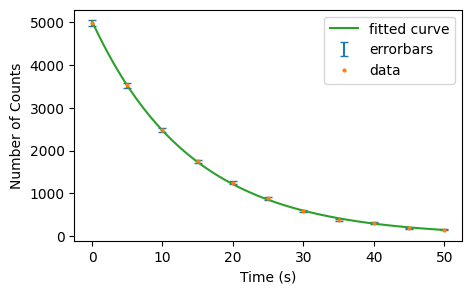

In [14]:
# define the parameters
t = np.linspace(0, 50, 100)  # Time from 0 to 50 seconds
N0 = p[0]                     # Initial count
lam = p[1]                   # Decay constant

# Calculate counts
decay_curve = nuclearcounts(t, N0, lam)

# Plot
plt.figure(figsize=(5, 3))
# Plot error bars only
plt.errorbar(
    decay_data['Time'], decay_data['Counts'],
    yerr=decay_data['Error'],
    fmt=' ', capsize=3, label='errorbars')
# Plot data points
plt.errorbar(
    decay_data['Time'], decay_data['Counts'],
    fmt='o', ms=2, label='data')
# Plot fitted curve
plt.plot(t, decay_curve, label='fitted curve')
# Axis labels and legend
plt.ylabel('Number of Counts')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

Note that I could have simply used the time data from the experiment to plot the decay curve. However, by defining a continuous time array I can get a smoother curve. This is particularly useful for visualising the overall shape of the decay without being limited to the discrete time points in the dataset.

From simply looking at this plot, you can see that the curve fits the data quite well. However, to obtain a numerical measure of the quality of the fit, we can calculate the reduced chi-squared statistic. This gives us a sense of how closely the model matches the data, taking into account the uncertainties in the measurements.
The reduced chi-squared is defined as:
$$\chi _{\nu }^2=\frac{1}{\nu }\sum _{i=1}^n\left( \frac{y_i-f(x_i)}{\sigma _i}\right) ^2$$
Where:
- $y_i$ are the observed data points,
- $f(x_i)$ are the model predictions,
- $\sigma_i$ are the uncertainties,
- $\nu =n-p$ is the number of degrees of freedom (number of data points minus number of fitted parameters).


In [15]:
# Recalculate fitted curve using experimental time points
fitted_counts = nuclearcounts(decay_data['Time'], p[0], p[1])

# Compute reduced chi-squared
residuals = decay_data['Counts'] - fitted_counts
dof = len(decay_data['Counts']) - len(p)
reduced_chi_squared = np.sum((residuals / decay_data['Error'])**2) / dof

print(f"Reduced chi-squared: {reduced_chi_squared:.2f}")

Reduced chi-squared: 1.08


This indicates that the fit was good. If the reduced chi-squared value $\chi _{\nu }^2$ were significantly greater than one, it would suggest that the fit was not good. Alternatively, if $\chi _{\nu }^2$ were far below one, it would imply that the model fits the data too well, which may indicate overfitting or that the uncertainties have been overestimated.